<a href="https://colab.research.google.com/github/Lohith2117/SRMS/blob/main/KNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os
import tensorflow as tf
from google.colab import userdata

# 1. Setup Kaggle Credentials
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Environment Ready!")

Environment Ready!


In [14]:
# 1. Download
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset

# 2. Unzip
import zipfile
with zipfile.ZipFile("kaggle-cat-vs-dog-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

# 3. Clean Corrupted Images
data_dir = 'data/kagglecatsanddogs_3367a/PetImages'
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(data_dir, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            # Check for valid image header
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()
        if not is_jfif:
            num_skipped += 1
            os.remove(fpath)
print(f"Deleted {num_skipped} corrupted images. Ready for training!")

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
kaggle-cat-vs-dog-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Deleted 1580 corrupted images. Ready for training!


Found 18704 images belonging to 2 classes.
Found 4675 images belonging to 2 classes.


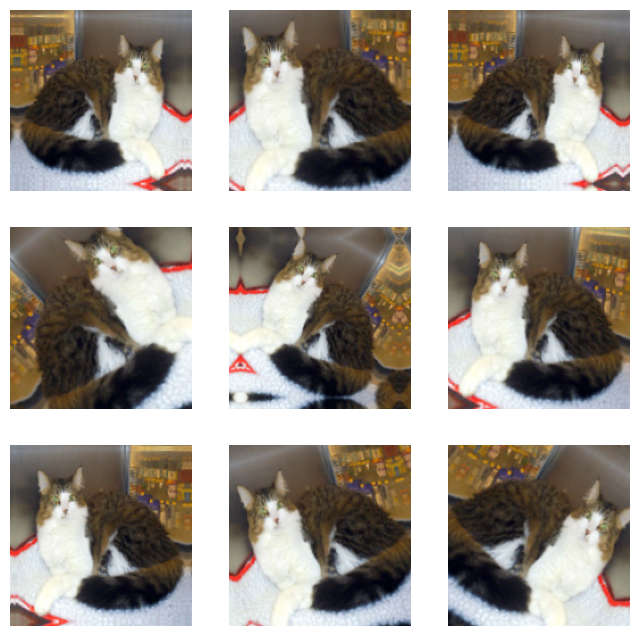

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Define Augmentation Logic
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

# 2. Setup Generators
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    data_dir, target_size=(160, 160), batch_size=32,
    class_mode='binary', subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir, target_size=(160, 160), batch_size=32,
    class_mode='binary', subset='validation'
)

# 3. Visualize Augmentation
images, _ = next(train_generator)
plt.figure(figsize=(8, 8))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    aug_img = data_augmentation(tf.expand_dims(images[0], 0))
    plt.imshow(aug_img[0])
    plt.axis("off")
plt.show()

In [18]:
# 1. Load Pre-trained Base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

# 2. Assemble the Model
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train
history = model.fit(train_generator, validation_data=val_generator, epochs=5)

Epoch 1/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 52s 81ms/step - accuracy: 0.9004 - loss: 0.2305 - val_accuracy: 0.9705 - val_loss: 0.0886
Epoch 2/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9248 - loss: 0.1796 - val_accuracy: 0.9726 - val_loss: 0.0819
Epoch 3/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9296 - loss: 0.1716 - val_accuracy: 0.9737 - val_loss: 0.0768
Epoch 4/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 47s 80ms/step - accuracy: 0.9308 - loss: 0.1673 - val_accuracy: 0.9743 - val_loss: 0.0732
Epoch 5/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - accuracy: 0.9300 - loss: 0.1646 - val_accuracy: 0.9754 - val_loss: 0.0701


In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. Plot Graphs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.legend()
plt.show()

# 2. Upload and Predict
print("\n--- UPLOAD YOUR IMAGE ---")
uploaded = files.upload()

for fn in uploaded.keys():
    img = image.load_img(fn, target_size=(160, 160))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    pred = model.predict(x)[0][0]
    label = "DOG" if pred > 0.5 else "CAT"
    print(f"\nResult: This is a {label} (Confidence: {pred if pred > 0.5 else 1-pred:.2%})")